# Notebook 7: Custom Stacking Ensemble
---
Custom stacking with XGBoost (two variants), Ridge, and Lasso as base estimators.

## Step 1: Feature Extraction Setup

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))

In [2]:
from scripts.data_utils import O4UHybridDataset, collate_fn

In [3]:
# ============================================
# Step 1: Setup & Data Loaders
# ============================================
import os
import json
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import warnings
warnings.filterwarnings("ignore")
os.environ["OMP_NUM_THREADS"] = "1"

from scripts.models import HybridFashionModel, FeatureExtractor
from scripts.config import DATA_PROCESSED_DIR, FEATURES_DIR as _FEATURES_DIR, SAVED_MODELS_DIR

device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Load phys_feature_cols from saved artifact — must match the trained model exactly
with open(SAVED_MODELS_DIR / "phys_feature_cols.json") as f:
    phys_feature_cols = json.load(f)
phys_dim_input = len(phys_feature_cols)
print(f"Physical feature dim: {phys_dim_input}")

FEATURES_DIR = str(_FEATURES_DIR)
df_train = pd.read_json(DATA_PROCESSED_DIR / "train_imputed_manifest.json")
df_val   = pd.read_json(DATA_PROCESSED_DIR / "val_imputed_manifest.json")

train_loader = DataLoader(O4UHybridDataset(df_train, FEATURES_DIR, phys_feature_cols),
                          batch_size=32, shuffle=False, collate_fn=collate_fn, num_workers=0)
val_loader   = DataLoader(O4UHybridDataset(df_val,   FEATURES_DIR, phys_feature_cols),
                          batch_size=32, shuffle=False, collate_fn=collate_fn, num_workers=0)
print("DataLoaders ready.")

Device: mps
Physical feature dim: 99
 Checking/Caching 10080 visual features...
 Checking/Caching 2520 visual features...
DataLoaders ready.


## Step 2: Feature Extraction

In [4]:
# ============================================
# Extract Features
# ============================================
model = HybridFashionModel(phys_input_dim=phys_dim_input).to(device)
checkpoint = torch.load(str(SAVED_MODELS_DIR / "best_hybrid_model.pth"), map_location=device, weights_only=True)
if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    model.load_state_dict(checkpoint["model_state_dict"])
else:
    model.load_state_dict(checkpoint)
model.eval()

extractor = FeatureExtractor(model).to(device)
extractor.eval()


def extract_features(loader, desc):
    features_list, labels_list = [], []
    with torch.inference_mode():
        # collate_fn returns: visual_padded, visual_mask, phys_vecs, reg_labels, bin_labels
        for visual_feat, visual_mask, phys_vecs, reg_labels, bin_labels in tqdm(loader, desc=desc):
            visual_feat = visual_feat.to(device)
            visual_mask = visual_mask.to(device)
            phys_vecs   = phys_vecs.to(device)
            fused = extractor(visual_feat, visual_mask, phys_vecs)
            features_list.append(fused.cpu().numpy())
            labels_list.append(bin_labels.numpy())
    return np.vstack(features_list), np.concatenate(labels_list)


X_train, y_train = extract_features(train_loader, "Train")
X_val,   y_val   = extract_features(val_loader,   "Val")
print(f"X_train: {X_train.shape}, X_val: {X_val.shape}")

del model, extractor, train_loader, val_loader
import gc; gc.collect()
print("PyTorch memory released.")

Train:   0%|          | 0/315 [00:00<?, ?it/s]

Val:   0%|          | 0/79 [00:00<?, ?it/s]

X_train: (10080, 256), X_val: (2520, 256)
PyTorch memory released.


## Step 3: Custom Stacking Ensemble (Baseline)

In [5]:
# ============================================
# Custom Stacking: XGBoost + Ridge + Lasso
# ============================================
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import RidgeClassifier, LogisticRegression
from xgboost import XGBClassifier

print("Training individual base models (Level 0)...\n")

base_estimators = [
    ("xgb1",  XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.05,
                             subsample=0.8, colsample_bytree=0.8,
                             eval_metric="logloss", random_state=42, n_jobs=1)),
    ("xgb2",  XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.08,
                             subsample=0.9, colsample_bytree=0.7,
                             eval_metric="logloss", random_state=0,  n_jobs=1)),
    ("ridge", RidgeClassifier(alpha=1.0, random_state=42)),
    ("lasso", LogisticRegression(penalty="l1", solver="liblinear", C=1.0, random_state=42)),
]

for name, est in base_estimators:
    est.fit(X_train, y_train)
    y_pred = est.predict(X_val)
    print(f"  {name:<6} | Acc: {accuracy_score(y_val, y_pred)*100:.2f}% | F1: {f1_score(y_val, y_pred, zero_division=0):.4f}")

print("\nTraining Stacking Ensemble (Level 1)...")

ensemble_model = StackingClassifier(
    estimators=base_estimators,
    final_estimator=LogisticRegression(random_state=42),
    cv=3, n_jobs=1,
)
ensemble_model.fit(X_train, y_train)

y_pred = ensemble_model.predict(X_val)
print(f"\nStacking Result:")
print(f"  Accuracy : {accuracy_score(y_val, y_pred)*100:.2f}%")
print(f"  F1-Score : {f1_score(y_val, y_pred, zero_division=0):.4f}")

Training individual base models (Level 0)...

  xgb1   | Acc: 90.32% | F1: 0.9202
  xgb2   | Acc: 90.20% | F1: 0.9190
  ridge  | Acc: 90.60% | F1: 0.9226
  lasso  | Acc: 90.20% | F1: 0.9191

Training Stacking Ensemble (Level 1)...

Stacking Result:
  Accuracy : 90.36%
  F1-Score : 0.9205


## Step 4: Optuna Tuning
---
CV on training set only to prevent leakage.

### Search Space Rationale

| Hyperparameter | Range | Rationale |
|---|---|---|
| `n_estimators` | [50, 500] | Project-wide standard. Aligned with NB05. |
| `max_depth` | [3, 10] | XGBoost trees are typically shallower than RF; depth 10 is sufficient. |
| `learning_rate` | [1e-3, 0.3] log | Very slow→moderate; above 0.3 risks instability. |
| `subsample` | [0.5, 1.0] | Row subsampling; below 0.5 produces high-variance trees. |
| `colsample_bytree` | [0.5, 1.0] | Column subsampling; mirrors subsample rationale. |
| `logreg_c` | [0.01, 10.0] log | Meta-learner regularization. Consistent with NB06. |

NB06 intentionally deviates by fixing `n_estimators=100` for RF (see NB06 rationale).

In [6]:
# ============================================
# Optuna Tuning (CV on train only)
# ============================================
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_curve

print("Running Optuna (30 trials, 3-fold CV on train)...")
optuna.logging.set_verbosity(optuna.logging.WARNING)


def objective(trial):
    logreg_c        = trial.suggest_float("logreg_c",        0.01, 10.0, log=True)
    n_estimators    = trial.suggest_int(  "n_estimators",    50,   500)
    max_depth       = trial.suggest_int(  "max_depth",       3,    10)
    learning_rate   = trial.suggest_float("learning_rate",   1e-3, 0.3,  log=True)
    subsample       = trial.suggest_float("subsample",       0.5,  1.0)
    colsample_bytree= trial.suggest_float("colsample_bytree",0.5,  1.0)

    base_estimators = [
        ("xgb1", XGBClassifier(
            n_estimators=n_estimators, max_depth=max_depth,
            learning_rate=learning_rate, subsample=subsample,
            colsample_bytree=colsample_bytree,
            eval_metric="logloss", random_state=42, n_jobs=1)),
        ("xgb2", XGBClassifier(
            n_estimators=max(50, n_estimators // 2),
            max_depth=max(3, max_depth - 1),
            learning_rate=min(learning_rate * 1.5, 0.3),
            subsample=subsample, colsample_bytree=colsample_bytree,
            eval_metric="logloss", random_state=0, n_jobs=1)),
        ("ridge", RidgeClassifier(alpha=1.0, random_state=42)),
        ("lasso", LogisticRegression(penalty="l1", solver="liblinear", C=1.0, random_state=42)),
    ]
    clf = StackingClassifier(
        estimators=base_estimators,
        final_estimator=LogisticRegression(C=logreg_c, max_iter=500, random_state=42),
        cv=2, n_jobs=1,
    )
    scores = cross_val_score(clf, X_train, y_train, cv=3, scoring="f1", n_jobs=1)
    return scores.mean()


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30, show_progress_bar=True)

print(f"\nBest params: {study.best_params}")
print(f"Best CV F1: {study.best_value:.4f}")

import json as _json
with open(str(SAVED_MODELS_DIR / "nb07_best_params.json"), "w") as _f:
    _json.dump(study.best_params, _f, indent=2)
print("Best params saved to saved_models/nb07_best_params.json")

Running Optuna (30 trials, 3-fold CV on train)...


  0%|          | 0/30 [00:00<?, ?it/s]


Best params: {'logreg_c': 0.06467009614919456, 'n_estimators': 390, 'max_depth': 4, 'learning_rate': 0.0206052845442199, 'subsample': 0.7881355605023348, 'colsample_bytree': 0.7161561661214149}
Best CV F1: 0.9392
Best params saved to saved_models/nb07_best_params.json


Optimal Threshold: 0.1386

Final Custom Stacking Metrics (Optimized):
  Accuracy  : 90.95%
  Precision : 87.78%
  Recall    : 98.09%
  F1-Score  : 0.9265


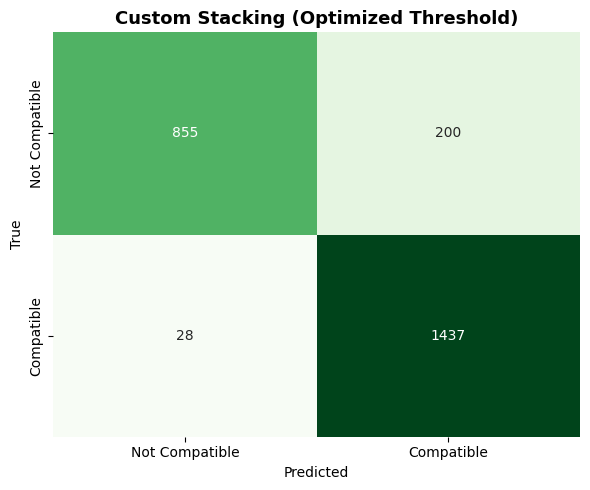

In [7]:
# ============================================
# Final Model + Threshold Optimization
# ============================================
p = study.best_params

base_estimators = [
    ("xgb1", XGBClassifier(
        n_estimators=p["n_estimators"], max_depth=p["max_depth"],
        learning_rate=p["learning_rate"], subsample=p["subsample"],
        colsample_bytree=p["colsample_bytree"],
        eval_metric="logloss", random_state=42, n_jobs=1)),
    ("xgb2", XGBClassifier(
        n_estimators=max(50, p["n_estimators"] // 2),
        max_depth=max(3, p["max_depth"] - 1),
        learning_rate=min(p["learning_rate"] * 1.5, 0.3),
        subsample=p["subsample"], colsample_bytree=p["colsample_bytree"],
        eval_metric="logloss", random_state=0, n_jobs=1)),
    ("ridge", RidgeClassifier(alpha=1.0, random_state=42)),
    ("lasso", LogisticRegression(penalty="l1", solver="liblinear", C=1.0, random_state=42)),
]

final_model = StackingClassifier(
    estimators=base_estimators,
    final_estimator=LogisticRegression(C=p["logreg_c"], max_iter=500, random_state=42),
    cv=5, n_jobs=1,
)
final_model.fit(X_train, y_train)

y_probs = final_model.predict_proba(X_val)[:, 1]
fpr, tpr, thresholds = roc_curve(y_val, y_probs)
opt_thr = thresholds[np.argmax(tpr - fpr)]

print(f"Optimal Threshold: {opt_thr:.4f}")

y_pred_opt = (y_probs >= opt_thr).astype(int)
print(f"\nFinal Custom Stacking Metrics (Optimized):")
print(f"  Accuracy  : {accuracy_score(y_val, y_pred_opt)*100:.2f}%")
print(f"  Precision : {precision_score(y_val, y_pred_opt, zero_division=0)*100:.2f}%")
print(f"  Recall    : {recall_score(y_val, y_pred_opt, zero_division=0)*100:.2f}%")
print(f"  F1-Score  : {f1_score(y_val, y_pred_opt, zero_division=0):.4f}")

cm = confusion_matrix(y_val, y_pred_opt)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", cbar=False,
            xticklabels=["Not Compatible", "Compatible"],
            yticklabels=["Not Compatible", "Compatible"])
plt.title("Custom Stacking (Optimized Threshold)", fontsize=13, fontweight="bold")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()